# Your Churn Model Tells You Who's Leaving, Not Who You Can Save
## Companion notebook — Uplift Modelling with a T-Learner on synthetic food delivery data

This notebook is the companion to the Medium post of the same name.  
It demonstrates the full pipeline end-to-end using **synthetic data with known ground-truth uplift** — so we can validate that the model recovers something close to the true treatment effect, which is impossible with real campaign data.

**What this notebook covers:**
1. Synthetic data generation — customers, randomised voucher treatment, ground-truth uplift
2. T-Learner with CatBoost, plus a calibration check against ground-truth τ
3. Budget curve — cumulative incremental orders: uplift-ranked vs churn-ranked vs random
4. Observable validation — estimating ATE from (T, Y) only, with confidence intervals
5. Profit analysis — deriving the optimal budget cutoff from campaign economics
6. BCG matrix — four quadrants from uplift and base scores

In [1]:
# Install dependencies if running in Colab
# !pip install catboost -q

In [2]:
import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

## 1. Synthetic Data Generation

We generate 20,000 customers with known ground-truth uplift τ. Synthetic data lets us construct it and verify the T-Learner recovers something close to the truth.

The simulation has five components: **customer features** (15 signals), **ground-truth τ** (persuadable score minus sleeping dog score), **randomised treatment** (50/50 coin flip), **observed outcomes** Y, and a **churn risk score** as the incumbent benchmark.

**Key design property:** churn risk and τ are driven by structurally different features — churn by recency and activity, τ by voucher sensitivity and moderate lapse window. This makes `Corr(churn, τ) ≈ 0` by construction.
> Distribution rationale and formula derivations: [`docs/synthetic_data_generation.md`](docs/synthetic_data_generation.md)

In [3]:
import sys
sys.path.insert(0, ".")

from src.dgp import generate_campaign_data

data = generate_campaign_data(n=20_000, seed=42)

X, feature_names = data["X"], data["feature_names"]
T, Y, tau        = data["T"], data["Y"], data["tau"]
base_p           = data["base_p"]
churn_risk       = data["churn_risk"]

print(f"Feature matrix: {X.shape}")
print(f"\nTreatment rate:       {T.mean():.2f}")
print(f"Overall conversion:   {Y.mean():.3f}")
print(f"Mean tau:             {tau.mean():.4f}")
print(f"Tau range:            [{tau.min():.3f}, {tau.max():.3f}]")
print(f"% negative tau:       {(tau < 0).mean():.1%}  (sleeping dogs)")
print(f"Corr(churn, tau):     {np.corrcoef(churn_risk, tau)[0,1]:.3f}  ← near zero by design")

pd.DataFrame(X[:5], columns=feature_names).round(2)

Feature matrix: (20000, 15)

Treatment rate:       0.50
Overall conversion:   0.389
Mean tau:             0.0984
Tau range:            [-0.256, 0.399]
% negative tau:       13.6%  (sleeping dogs)
Corr(churn, tau):     0.084  ← near zero by design


,days_since_last_order,orders_last_30d,orders_last_90d,avg_order_value,voucher_use_rate,voucher_orders_last_90d,distinct_cuisines_30d,support_tickets_open,days_since_bad_experience,tenure_days,session_days_last_14d,avg_delivery_time,refund_rate,email_open_rate_30d,push_open_rate_30d
0,33.66,2.0,7.0,30.32,0.15,1.0,1.0,1.0,26.70,326.44,6.0,34.72,0.12,0.26,0.31
1,32.71,2.0,7.0,31.16,0.30,2.0,2.0,0.0,31.41,131.17,4.0,32.57,0.02,0.19,0.17
2,33.39,0.0,0.0,23.01,0.47,0.0,3.0,1.0,90.52,177.36,5.0,36.25,0.04,0.26,0.16
3,3.92,5.0,17.0,6.96,0.07,1.0,1.0,1.0,16.58,34.58,1.0,36.77,0.01,0.15,0.01
4,1.21,4.0,13.0,19.16,0.54,6.0,4.0,0.0,16.65,222.01,2.0,32.72,0.01,0.29,0.10


## 2. T-Learner with CatBoost

The T-Learner (two-model approach) fits separate models on the control and treated populations,
then takes the difference of their predictions as the uplift score.

```
uplift(x) = P(Y=1 | X=x, T=1) - P(Y=1 | X=x, T=0)
           = m1(x) - m0(x)
```

**Why CatBoost:**
- Handles mixed feature types without encoding overhead  
- Symmetric trees reduce overfitting on the smaller treated/control splits
- Fast to tune for a notebook demo

In [4]:
(X_tr, X_te, T_tr, T_te, Y_tr, Y_te, tau_tr, tau_te, base_tr, base_te, churn_tr, churn_te) = \
    train_test_split(X, T, Y, tau, base_p, churn_risk, test_size=0.3, random_state=42)

params = dict(iterations=300, depth=4, learning_rate=0.05,
              eval_metric="AUC", random_seed=42, verbose=0)

# Control model: P(Y=1 | X, T=0)
m0 = CatBoostClassifier(**params)
m0.fit(X_tr[T_tr == 0], Y_tr[T_tr == 0])

# Treated model: P(Y=1 | X, T=1)
m1 = CatBoostClassifier(**params)
m1.fit(X_tr[T_tr == 1], Y_tr[T_tr == 1])

uplift_score = m1.predict_proba(X_te)[:, 1] - m0.predict_proba(X_te)[:, 1]
base_score   = m0.predict_proba(X_te)[:, 1]

corr = np.corrcoef(uplift_score, tau_te)[0, 1]
print(f"Corr(uplift_score, ground_truth_tau): {corr:.3f}")
print(f"Uplift score range: [{uplift_score.min():.3f}, {uplift_score.max():.3f}]")

Corr(uplift_score, ground_truth_tau): 0.691
Uplift score range: [-0.338, 0.513]


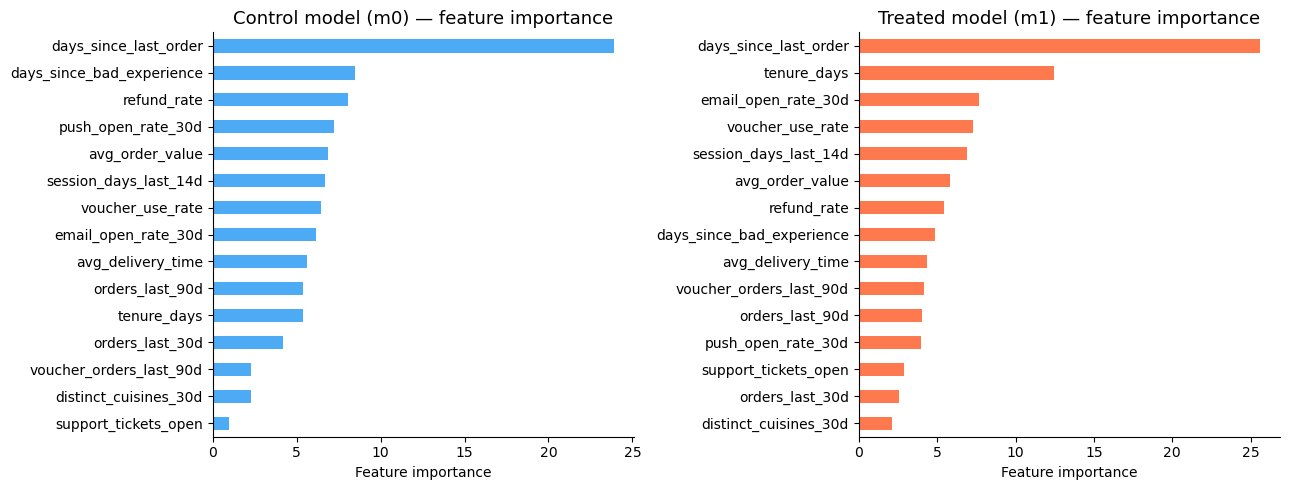


Note: voucher_use_rate and email_open_rate_30d appear more prominently in m1 (treated)
than m0 — consistent with how ground-truth tau was constructed.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#2196F3", "#FF5722"]
titles = ["Control model (m0) — feature importance", "Treated model (m1) — feature importance"]

for ax, model, color, title in zip(axes, [m0, m1], colors, titles):
    imp = pd.Series(model.get_feature_importance(), index=feature_names).sort_values()
    imp.plot(kind="barh", ax=ax, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Feature importance")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nNote: voucher_use_rate and email_open_rate_30d appear more prominently in m1 (treated)")
print("than m0 — consistent with how ground-truth tau was constructed.")

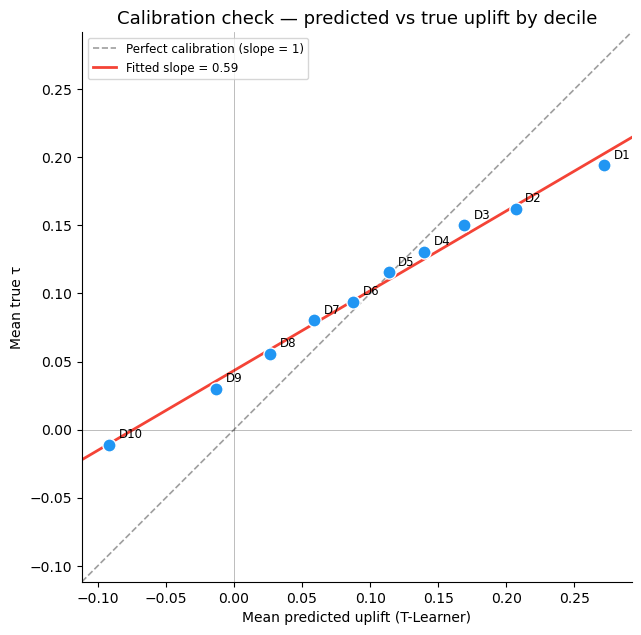

Calibration slope:  0.586  (1.0 = perfectly calibrated)
Predicted spread across deciles: 0.364
True spread across deciles:      0.206
→ Slope < 1: the T-Learner is over-dispersed — its extreme deciles are more extreme
  than the truth. Treat the score as a ranking signal, not a literal probability shift.

Caution: D9 predicted -0.013 but true τ is +0.030 — opposite sign. A sign-based suppression rule would misclassify this segment.


In [6]:
calib_df = pd.DataFrame({"uplift_score": uplift_score, "tau": tau_te})
calib_df["decile"] = pd.qcut(-calib_df["uplift_score"], q=10, labels=range(1, 11))
calib = (
    calib_df.groupby("decile", observed=True)
    .agg(pred=("uplift_score", "mean"), true=("tau", "mean"), n=("tau", "count"))
    .reset_index()
)

slope, intercept = np.polyfit(calib["pred"], calib["true"], 1)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
lims = [
    min(calib["pred"].min(), calib["true"].min()) - 0.02,
    max(calib["pred"].max(), calib["true"].max()) + 0.02,
]
ax.plot(lims, lims, color="#9E9E9E", lw=1.2, ls="--", label="Perfect calibration (slope = 1)")
ax.plot(lims, [slope * x + intercept for x in lims], color="#F44336", lw=2,
        label=f"Fitted slope = {slope:.2f}")
ax.scatter(calib["pred"], calib["true"], s=90, color="#2196F3", zorder=3, edgecolor="white")
for _, row in calib.iterrows():
    ax.annotate(f"D{int(row['decile'])}", (row["pred"], row["true"]),
                textcoords="offset points", xytext=(7, 5), fontsize=8.5)

ax.axhline(0, color="black", lw=0.6, alpha=0.3)
ax.axvline(0, color="black", lw=0.6, alpha=0.3)
ax.set_xlabel("Mean predicted uplift (T-Learner)")
ax.set_ylabel("Mean true τ")
ax.set_title("Calibration check — predicted vs true uplift by decile")
ax.legend(fontsize=8.5, loc="upper left")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("images/calibration_check.png", dpi=150, bbox_inches="tight")
plt.show()

pred_spread = calib["pred"].max() - calib["pred"].min()
true_spread = calib["true"].max() - calib["true"].min()
print(f"Calibration slope:  {slope:.3f}  (1.0 = perfectly calibrated)")
print(f"Predicted spread across deciles: {pred_spread:.3f}")
print(f"True spread across deciles:      {true_spread:.3f}")
if slope < 0.9:
    print(f"→ Slope < 1: the T-Learner is over-dispersed — its extreme deciles are more extreme")
    print(f"  than the truth. Treat the score as a ranking signal, not a literal probability shift.")

# Flag any decile where the predicted sign disagrees with the true sign —
# a targeting rule that suppresses by raw score sign would misclassify these
sign_flips = calib[((calib["pred"] < 0) & (calib["true"] > 0)) | ((calib["pred"] > 0) & (calib["true"] < 0))]
for _, row in sign_flips.iterrows():
    print(f"\nCaution: D{int(row['decile'])} predicted {row['pred']:+.3f} but true τ is {row['true']:+.3f}"
          f" — opposite sign. A sign-based suppression rule would misclassify this segment.")

### _Calibration check — does the T-Learner over- or under-state the truth?_

The T-Learner markdown above already flags the risk: *"each model carries its own estimation error, and those errors compound in the difference."* Here we check whether that's actually happening, rather than leaving it as an asserted caveat.

Bin the test set into deciles by predicted uplift, then compare the **mean predicted uplift** against the **mean true τ** in each bin. If the model were perfectly calibrated, every point would sit on the 45° line — a slope of 1.0.

A slope below 1.0 means the model is **over-dispersed**: it pushes its highest and lowest deciles further from the center than the truth actually is. That's a meaningfully different failure mode from "the ranking is wrong" — the *ordering* can still be useful even when the *magnitude* is inflated, but it means the raw score should not be read as a literal probability shift, and any decile near zero deserves a second look before you act on its sign.

## 3. Budget Curve — The Argument in One Chart

With a fixed voucher budget, targeting is an **allocation problem**.  
Every voucher sent to the wrong customer is one not sent to a persuadable.

This chart shows cumulative incremental orders as a function of how many customers
you treat, under three ranking strategies:

- **Uplift-ranked** — rank by the T-learner score (descending)
- **Random** — no targeting; baseline

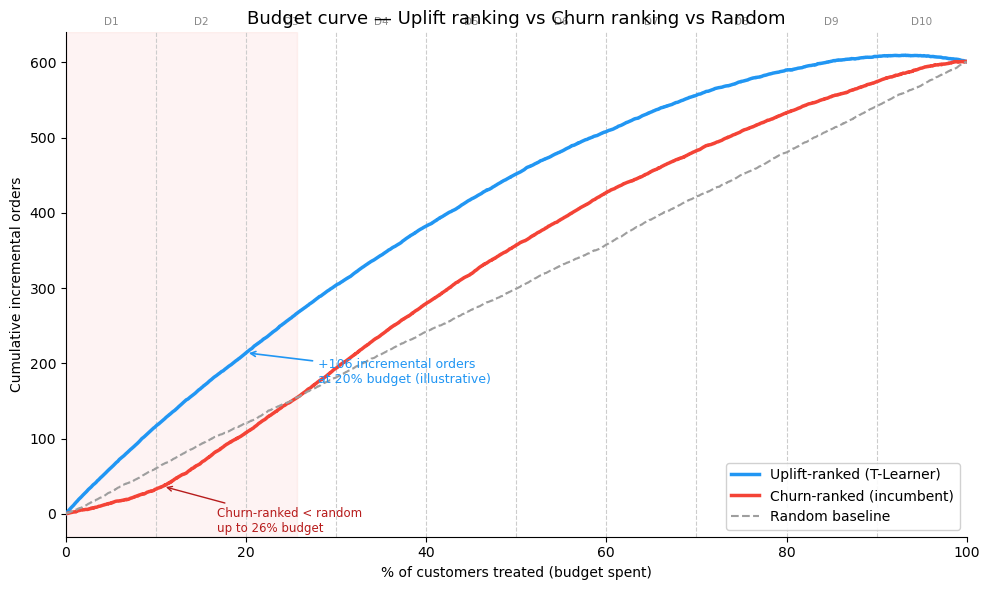

At 20% budget (illustrative reference point):
  Uplift-ranked:  214.0 incremental orders
  Churn-ranked:   107.8 incremental orders
  Random:         120.7 incremental orders
  Gap (uplift vs churn): +106.2 orders — 98.6% more

Churn-ranking underperforms RANDOM targeting for the first 26% of budget
(worst at 11%: 29 fewer incremental orders than doing no targeting at all).
Mechanism: churn risk loads heavily on recency (days_since_last_order), which pushes the
most-lapsed customers to the top of the churn-ranked list — but the persuadable window in
this DGP is 10–25 days. The customers churn-ranking is MOST confident about are the ones
who are already past the point where a voucher can recover them.

(The actual budget-size recommendation — how far down the list to go — is derived from
unit economics, not from this comparison. See Section 5.)


In [7]:
n_te = len(tau_te)
budget_pct = np.linspace(0, 1, n_te + 1)

def cumulative_incremental(order_idx, tau):
    return np.concatenate([[0], np.cumsum(tau[order_idx])])

uplift_order = np.argsort(-uplift_score)
churn_order  = np.argsort(-churn_te)
random_order = np.random.RandomState(0).permutation(n_te)

cum_uplift = cumulative_incremental(uplift_order, tau_te)
cum_churn  = cumulative_incremental(churn_order,  tau_te)
cum_random = cumulative_incremental(random_order, tau_te)

# Where does churn-ranking stop being WORSE than doing no targeting at all?
diff = cum_churn - cum_random
sign_changes = np.where(np.diff(np.sign(diff[1:])) > 0)[0]
crossover_idx = int(sign_changes[0]) + 1 if len(sign_changes) else 0
crossover_pct = round(100 * crossover_idx / n_te, 1)

fig, ax = plt.subplots(figsize=(10, 6))

# Decile boundary lines — one vertical per decile break
for d in range(1, 10):
    ax.axvline(d * 10, color="#CCCCCC", lw=0.8, ls="--", zorder=1)
for d in range(1, 11):
    ax.text(d * 10 - 5, 1.01, f"D{d}", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=7.5, color="#888888")

# Shade the region where churn-ranking underperforms random targeting
if crossover_idx > 0:
    ax.axvspan(0, crossover_pct, color="#F44336", alpha=0.06, zorder=0)

ax.plot(budget_pct * 100, cum_uplift, color="#2196F3", lw=2.5, label="Uplift-ranked (T-Learner)", zorder=3)
ax.plot(budget_pct * 100, cum_churn,  color="#F44336", lw=2.5, label="Churn-ranked (incumbent)", zorder=3)
ax.plot(budget_pct * 100, cum_random, color="#9E9E9E", lw=1.5, ls="--", label="Random baseline", zorder=3)

# Annotate the gap at an illustrative 20% budget mark (NOT a recommendation —
# the actual budget-size recommendation is derived from economics in Section 5)
illustrative_mark = 20
idx = int(n_te * illustrative_mark / 100)
gap = cum_uplift[idx] - cum_churn[idx]
ax.annotate(
    f"+{gap:.0f} incremental orders\nat {illustrative_mark}% budget (illustrative)",
    xy=(illustrative_mark, cum_uplift[idx]),
    xytext=(illustrative_mark + 8, cum_uplift[idx] - 40),
    fontsize=9, color="#2196F3",
    arrowprops=dict(arrowstyle="->", color="#2196F3", lw=1.2),
)

if crossover_idx > 0:
    worst_i = int(np.argmin(diff[:crossover_idx + 1]))
    worst_pct = round(100 * worst_i / n_te, 1)
    ax.annotate(
        f"Churn-ranked < random\nup to {crossover_pct:.0f}% budget",
        xy=(worst_pct, cum_churn[worst_i]),
        xytext=(worst_pct + 6, cum_churn[worst_i] - 60),
        fontsize=8.5, color="#B71C1C",
        arrowprops=dict(arrowstyle="->", color="#B71C1C", lw=1.0),
    )

ax.set_xlabel("% of customers treated (budget spent)")
ax.set_ylabel("Cumulative incremental orders")
ax.set_title("Budget curve — Uplift ranking vs Churn ranking vs Random")
ax.legend(framealpha=0.9)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig("images/budget_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"At {illustrative_mark}% budget (illustrative reference point):")
print(f"  Uplift-ranked:  {cum_uplift[idx]:.1f} incremental orders")
print(f"  Churn-ranked:   {cum_churn[idx]:.1f} incremental orders")
print(f"  Random:         {cum_random[idx]:.1f} incremental orders")
print(f"  Gap (uplift vs churn): +{gap:.1f} orders — {gap/cum_churn[idx]*100:.1f}% more")

if crossover_idx > 0:
    worst_gap = cum_random[worst_i] - cum_churn[worst_i]
    print(f"\nChurn-ranking underperforms RANDOM targeting for the first {crossover_pct:.0f}% of budget")
    print(f"(worst at {worst_pct:.0f}%: {worst_gap:.0f} fewer incremental orders than doing no targeting at all).")
    print(f"Mechanism: churn risk loads heavily on recency (days_since_last_order), which pushes the")
    print(f"most-lapsed customers to the top of the churn-ranked list — but the persuadable window in")
    print(f"this DGP is 10–25 days. The customers churn-ranking is MOST confident about are the ones")
    print(f"who are already past the point where a voucher can recover them.")
print(f"\n(The actual budget-size recommendation — how far down the list to go — is derived from")
print(f"unit economics, not from this comparison. See Section 5.)")

### Decile analysis — Persuadables vs others

Splitting customers into 10 equal groups by predicted uplift score (D1 = highest, D10 = lowest) makes the targeting decision concrete:

- **D1–D3 (top 30%):** strong positive uplift → **Persuadables**, highest ROI for voucher spend
- **D4–D7 (middle 40%):** diminishing incremental effect → marginal targeting value
- **D8–D10 (bottom 30%):** near-zero or negative uplift → **Lost Causes** and **Sleeping Dogs**

The left panel shows the model's predicted uplift per decile; the right panel validates against ground-truth τ. A monotonically descending pattern in both confirms the model's ranking is meaningful.


Decile summary (predicted vs ground-truth):
decile  pred_uplift  true_tau   n
     1     0.272099  0.194260 600
     2     0.206889  0.162377 600
     3     0.169290  0.149933 600
     4     0.139555  0.130783 600
     5     0.113547  0.115602 600
     6     0.087735  0.093913 600
     7     0.058735  0.080371 600
     8     0.026270  0.055732 600
     9    -0.013454  0.030066 600
    10    -0.091794 -0.011309 600

Persuadables:    deciles [1, 2, 3, 4, 5, 6, 7]  → top 70% of ranked list
Neutral:         deciles [8]
Sleeping Dogs:   deciles [9, 10]  → bottom 20%


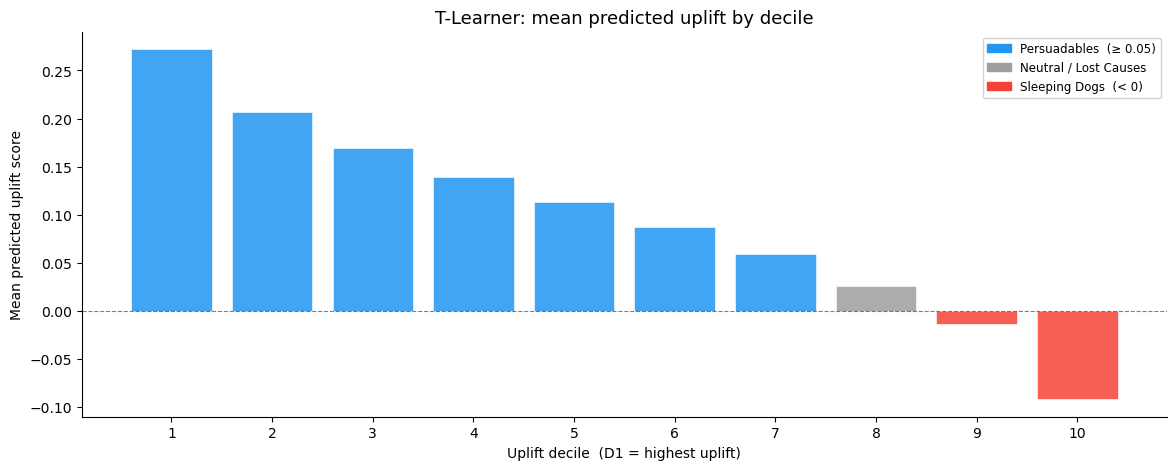

In [8]:
results_te = pd.DataFrame({
    "uplift_score": uplift_score,
    "tau":          tau_te,
    "churn_risk":   churn_te,
    "base_score":   base_score,
})

# Decile 1 = highest uplift (most persuadable), Decile 10 = lowest
results_te["decile"] = pd.qcut(-results_te["uplift_score"], q=10, labels=range(1, 11))

decile_summary = (
    results_te.groupby("decile")
    .agg(mean_uplift=("uplift_score", "mean"), mean_tau=("tau", "mean"), n=("uplift_score", "count"))
    .reset_index()
)

def bar_color(u):
    if u >= 0.05:
        return "#2196F3"    # Persuadable
    elif u < 0.0:
        return "#F44336"    # Sleeping Dog
    else:
        return "#9E9E9E"    # Lost Cause / neutral

colors_d = [bar_color(u) for u in decile_summary["mean_uplift"]]

fig, axes = plt.subplots(1, 1, figsize=(14, 5))

# Left: predicted uplift per decile
ax = axes
ax.bar(decile_summary["decile"].astype(str), decile_summary["mean_uplift"],
       color=colors_d, alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Uplift decile  (D1 = highest uplift)")
ax.set_ylabel("Mean predicted uplift score")
ax.set_title("T-Learner: mean predicted uplift by decile")
ax.legend(handles=[
    mpatches.Patch(color="#2196F3", label="Persuadables  (≥ 0.05)"),
    mpatches.Patch(color="#9E9E9E", label="Neutral / Lost Causes"),
    mpatches.Patch(color="#F44336", label="Sleeping Dogs  (< 0)"),
], fontsize=8.5, framealpha=0.9)

print("\nDecile summary (predicted vs ground-truth):")
print(decile_summary.rename(columns={"mean_uplift": "pred_uplift", "mean_tau": "true_tau"}).to_string(index=False))

persuadable_deciles  = decile_summary[decile_summary["mean_uplift"] >= 0.05]["decile"].tolist()
neutral_deciles      = decile_summary[(decile_summary["mean_uplift"] >= 0) & (decile_summary["mean_uplift"] < 0.05)]["decile"].tolist()
sleeping_dog_deciles = decile_summary[decile_summary["mean_uplift"] < 0]["decile"].tolist()

print(f"\nPersuadables:    deciles {persuadable_deciles}  → top {len(persuadable_deciles) * 10}% of ranked list")
print(f"Neutral:         deciles {neutral_deciles}")
print(f"Sleeping Dogs:   deciles {sleeping_dog_deciles}  → bottom {len(sleeping_dog_deciles) * 10}%")

### Observable validation — how can can we evaluate?

After running a voucher campaign you observe two things: **T** (who received the voucher) and **Y** (did they order). That's it — no τ. The question is whether you can still tell if your model's ranking produced real incremental lift using only what a live campaign would actually give you.

The difference in observed conversion rates between treated and control customers *within each decile* is an unbiased estimate of the average treatment effect in that decile — derived purely from observed data, no ground truth required.

**The cell below is the actual production report** — decile-level observable ATE with 95% confidence intervals, and the cumulative observable curve. This is everything you'd see in a real campaign with no τ available.

**The cell after that is commented out.** It's not part of a real evaluation — it exists only because this notebook uses synthetic data with a known ground-truth τ, letting us check that the observable method above genuinely recovers something close to the truth. Uncomment it if you want to see that validation for yourself; a live campaign would never have this comparison available.

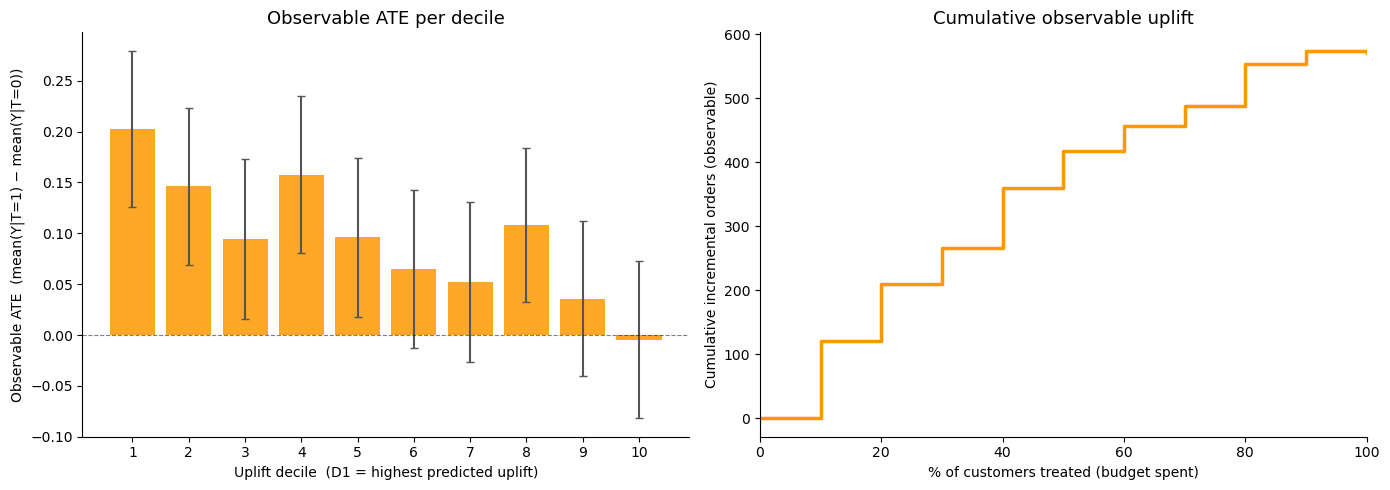

Mean 95% CI half-width on observable ATE: ±0.077
9/9 adjacent decile pairs are not statistically distinguishable at this sample size.

 decile  obs_ate   ci95  redeem_rate   n
      1   0.2027 0.0769       0.5079 600
      2   0.1460 0.0775       0.4667 600
      3   0.0942 0.0788       0.4746 600
      4   0.1578 0.0777       0.4888 600
      5   0.0961 0.0780       0.4466 600
      6   0.0646 0.0777       0.4183 600
      7   0.0523 0.0788       0.4419 600
      8   0.1081 0.0753       0.3943 600
      9   0.0356 0.0761       0.3645 600
     10  -0.0047 0.0772       0.3660 600


In [9]:
# ── PRODUCTION REPORT ──────────────────────────────────────────────────────
# What you'd actually have after a live campaign: model predictions (uplift_score),
# who was treated (T), and what happened (Y). No ground-truth tau exists here —
# this cell doesn't reference it at all.

eval_df = pd.DataFrame({
    "uplift_score": uplift_score,
    "T":            T_te,
    "Y":            Y_te,
})
eval_df["decile"] = pd.qcut(-eval_df["uplift_score"], q=10, labels=range(1, 11))

rows = []
for k, g in eval_df.groupby("decile", observed=True):
    t, c = g[g["T"] == 1], g[g["T"] == 0]
    p_t, p_c, n_t, n_c = t["Y"].mean(), c["Y"].mean(), len(t), len(c)
    se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
    rows.append(dict(
        decile=int(k), obs_ate=p_t - p_c, se=se, ci95=1.96 * se,
        redeem_rate=p_t, n=len(g),
    ))
decile_eval = pd.DataFrame(rows)

cum_obs = np.concatenate([[0], np.cumsum(decile_eval["n"] * decile_eval["obs_ate"])])
step_x  = np.arange(0, 11) * 10   # 0, 10, 20, ..., 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: observable ATE per decile, with 95% CI ──────────────────────────
ax = axes[0]
ax.bar(decile_eval["decile"].astype(str), decile_eval["obs_ate"],
       yerr=decile_eval["ci95"], capsize=3, ecolor="#555555",
       color="#FF9800", alpha=0.85)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Uplift decile  (D1 = highest predicted uplift)")
ax.set_ylabel("Observable ATE  (mean(Y|T=1) − mean(Y|T=0))")
ax.set_title("Observable ATE per decile")

# ── Right: cumulative observable incremental orders ───────────────────────
ax2 = axes[1]
ax2.step(step_x, cum_obs, color="#FF9800", lw=2.5, where="post")
ax2.set_xlabel("% of customers treated (budget spent)")
ax2.set_ylabel("Cumulative incremental orders (observable)")
ax2.set_title("Cumulative observable uplift")
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.savefig("images/observable_validation.png", dpi=150, bbox_inches="tight")
plt.show()

mean_ci = decile_eval["ci95"].mean()
overlaps = sum(
    abs(decile_eval["obs_ate"][i] - decile_eval["obs_ate"][i+1])
    < (decile_eval["ci95"][i] + decile_eval["ci95"][i+1])
    for i in range(len(decile_eval) - 1)
)
print(f"Mean 95% CI half-width on observable ATE: ±{mean_ci:.3f}")
print(f"{overlaps}/9 adjacent decile pairs are not statistically distinguishable at this sample size.\n")
print(decile_eval[["decile", "obs_ate", "ci95", "redeem_rate", "n"]].round(4).to_string(index=False))

### Appendix — validating against synthetic ground truth (not part of a real evaluation)

The cell below is **commented out**. It reproduces the same decile bins as the production report above, but adds a side-by-side comparison against `tau` — the true, simulated treatment effect. That comparison is only possible here because this notebook uses synthetic data with a known ground truth; a real campaign never has it.

Uncomment and run it if you want to see, concretely, that the oracle-free method above actually recovers something close to the truth (`Corr(oracle τ, observable ATE) ≈ 0.876` last time this was run).

In [10]:
# # Build evaluation dataframe — T and Y are all you'd have in a real campaign
# eval_df = pd.DataFrame({
#     "uplift_score": uplift_score,
#     "tau":          tau_te,
#     "T":            T_te,
#     "Y":            Y_te,
# })
# eval_df["decile"] = pd.qcut(-eval_df["uplift_score"], q=10, labels=range(1, 11))
#
# # Observable ATE per decile: mean(Y|T=1) − mean(Y|T=0), with a standard error
# rows = []
# for k, g in eval_df.groupby("decile", observed=True):
#     t, c = g[g["T"] == 1], g[g["T"] == 0]
#     p_t, p_c, n_t, n_c = t["Y"].mean(), c["Y"].mean(), len(t), len(c)
#     se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
#     rows.append(dict(
#         decile=int(k), oracle_tau=g["tau"].mean(), obs_ate=p_t - p_c,
#         se=se, ci95=1.96 * se, redeem_rate=p_t, n=len(g),
#     ))
# decile_eval = pd.DataFrame(rows)
#
# # Observable cumulative step curve (n_decile × obs_ate, accumulated)
# cum_obs = np.concatenate([[0], np.cumsum(decile_eval["n"] * decile_eval["obs_ate"])])
# step_x  = np.arange(0, 11) * 10   # 0, 10, 20, ..., 100
#
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#
# # ── Left: oracle vs observable ATE per decile, with 95% CI on the observable ──
# ax = axes[0]
# x, w = np.arange(1, 11), 0.35
# ax.bar(x - w/2, decile_eval["oracle_tau"], w, color="#2196F3", alpha=0.85, label="Oracle  (ground-truth τ)")
# ax.bar(x + w/2, decile_eval["obs_ate"],    w, color="#FF9800", alpha=0.85,
#        yerr=decile_eval["ci95"], capsize=3, ecolor="#555555",
#        label="Observable  (mean(Y|T=1) − mean(Y|T=0)) ± 95% CI")
# ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
# ax.set_xticks(x)
# ax.set_xticklabels([f"D{i}" for i in x])
# ax.set_xlabel("Uplift decile  (D1 = highest predicted uplift)")
# ax.set_ylabel("Average treatment effect")
# ax.set_title("Oracle vs observable ATE per decile")
# ax.legend(fontsize=8.5, framealpha=0.9)
#
# # ── Right: cumulative uplift — oracle (smooth) vs observable (step) ─────────
# ax2 = axes[1]
# ax2.plot(budget_pct * 100, cum_uplift, color="#2196F3", lw=2.5, label="Oracle  (ground-truth τ)")
# ax2.step(step_x, cum_obs, color="#FF9800", lw=2.5, where="post", label="Observable  (decile ATE × n)")
# ax2.set_xlabel("% of customers treated (budget spent)")
# ax2.set_ylabel("Cumulative incremental orders")
# ax2.set_title("Cumulative uplift — oracle vs observable")
# ax2.legend(fontsize=9, framealpha=0.9)
# ax2.set_xlim(0, 100)
#
# plt.tight_layout()
# plt.savefig("images/observable_validation_appendix.png", dpi=150, bbox_inches="tight")
# plt.show()
#
# corr = np.corrcoef(decile_eval["oracle_tau"], decile_eval["obs_ate"])[0, 1]
# print(f"Corr(oracle τ, observable ATE) across deciles: {corr:.3f}")
#
# # Per-decile n=600 gives wide CIs — quantify how much of the true signal that noise band covers
# mean_ci      = decile_eval["ci95"].mean()
# true_spread  = decile_eval["oracle_tau"].max() - decile_eval["oracle_tau"].min()
# print(f"Mean 95% CI half-width on observable ATE: ±{mean_ci:.3f}")
# print(f"True τ spread across all 10 deciles:        {true_spread:.3f}")
# print(f"→ the CI band is {2*mean_ci/true_spread:.0%} of the entire signal range — individual deciles")
# print(f"  are noisy on their own; treat the ranking as directionally reliable, not decile-exact.")
#
# # Flag adjacent-decile pairs where observable ATE is *not* statistically distinguishable
# overlaps = sum(
#     abs(decile_eval["obs_ate"][i] - decile_eval["obs_ate"][i+1])
#     < (decile_eval["ci95"][i] + decile_eval["ci95"][i+1])
#     for i in range(len(decile_eval) - 1)
# )
# print(f"{overlaps}/9 adjacent decile pairs are not statistically distinguishable at this sample size.\n")
# print(decile_eval[["decile", "oracle_tau", "obs_ate", "ci95", "redeem_rate", "n"]].round(4).to_string(index=False))

### Profit analysis — deriving the optimal budget cutoff

Knowing *which* customers have positive uplift is half the answer. The other half is knowing *how far down the ranked list* it is worth going — and that requires putting economics into the model.

This is the question Section 3 deliberately deferred: the 20% budget mark used there was illustrative, chosen only to demonstrate the uplift-vs-churn gap. It was never a recommendation. The actual cutoff comes from unit economics, computed here.

Three parameters convert the uplift scores into a profit recommendation:

| Parameter | Symbol | What it captures |
|---|---|---|
| Average order value | `aov` | Revenue per order placed |
| Contribution margin | `margin_rate` | Profit retained per order after costs |
| Voucher value | `discount_value` | Discount paid — but **only when the voucher is redeemed** |

**Why redemption matters, not just targeting:** a flat cost-per-customer-targeted model misses the mechanism that makes uplift targeting valuable in the first place. A voucher costs you money whether or not it created a new order — Sure Things redeem at high rates with near-zero incremental effect, so the discount leaks out as pure margin loss on orders you'd have gotten anyway. The corrected model charges the discount on `redeem_rate` (observed redemption in that decile), not on everyone targeted:

```
margin_per_customer = obs_ate × margin_rate × aov  −  send_cost  −  redeem_rate × discount_value
```

**The cutoff rule:** the optimal stopping point is where **cumulative** profit is maximised — `argmax(cumsum(decile_profit))` — not the last decile with a positive per-customer margin. A mid-list decile that happens to be marginally profitable doesn't retroactively justify treating the loss-making deciles before it; only the running total matters.

**Left panel:** marginal profit per customer by decile, with 95% CIs propagated from the observable ATE's sampling error — the same uncertainty from the previous section, carried through to the money.

**Right panel:** cumulative profit with a shaded confidence band. The recommendation quotes both the point-estimate peak *and* the range of cutoffs that are statistically indistinguishable from it — a defensible "treat roughly the top N%," not false precision on a single decile.

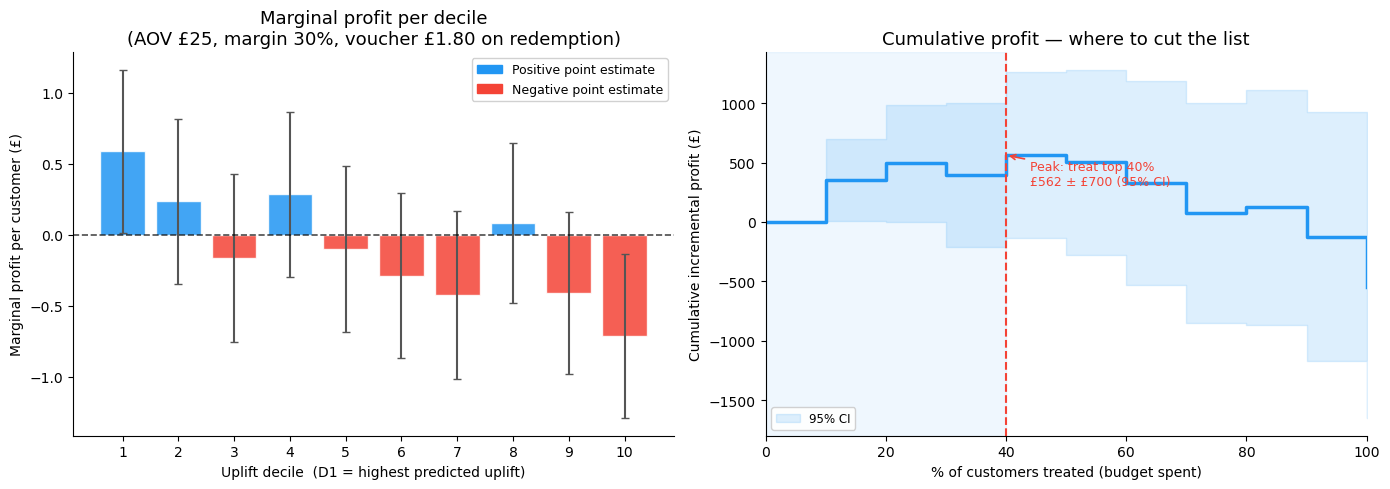

Parameters: AOV £25.0 | margin 30% | send £0.02 | voucher £1.8 (on redemption)
Point-estimate peak: treat D1–D4  →  top 40% of uplift-ranked list
Cumulative profit at peak: £562 ± £700 (95% CI)

This is the answer to the question Section 3 deferred: 20% there was used
purely to illustrate the uplift-vs-churn gap. The economics here derive 40% independently —
there is no reason to expect the two figures to match, and they don't.

Cutoffs within noise of the peak: D1–D9 — treat the point
estimate (D4) as a reasonable operating point, not a precise cutoff.

 decile  obs_ate  redeem_rate  margin_per_customer  decile_profit
      1    0.203        0.508                0.586        351.459
      2    0.146        0.467                0.235        141.143
      3    0.094        0.475               -0.167       -100.425
      4    0.158        0.489                0.284        170.210
      5    0.096        0.447               -0.103        -61.941
      6    0.065        0.418              

In [11]:
# ── Campaign economics (adjust to your context) ───────────────────────────
aov            = 25.0   # £ — average order value
margin_rate    = 0.30   # contribution margin on each order
send_cost      = 0.02   # £ — cost of sending the notification/email itself
discount_value = 1.80   # £ — value of the voucher, paid ONLY when redeemed

# Marginal profit per customer treated in decile k:
#   upside = incremental orders created  ×  margin per order          (from obs_ate)
#   cost   = send_cost (everyone) + discount_value × redemption rate  (only who orders)
#
# This is the leakage term that makes targeting matter: the discount is paid on
# EVERY redemption — including Sure Things who would have ordered anyway — not
# just on the incremental orders the voucher created.
decile_eval["margin_per_customer"] = (
    decile_eval["obs_ate"] * margin_rate * aov
    - send_cost
    - decile_eval["redeem_rate"] * discount_value
)
decile_eval["decile_profit"] = decile_eval["n"] * decile_eval["margin_per_customer"]

# Propagate the observable-ATE uncertainty into the profit estimate
decile_eval["se_margin"] = margin_rate * aov * decile_eval["se"]
decile_eval["se_decile_profit"] = decile_eval["n"] * decile_eval["se_margin"]

# Cumulative profit — the CORRECT stopping rule is where this peaks, not the
# last decile with a positive per-customer margin (a mid-list positive decile
# doesn't retroactively make the loss-making deciles before it worth including)
cum_profit    = np.concatenate([[0], np.cumsum(decile_eval["decile_profit"])])
se_cum_profit = np.concatenate([[0], np.sqrt(np.cumsum(decile_eval["se_decile_profit"]**2))])
step_x        = np.arange(0, 11) * 10

optimal_idx  = int(np.argmax(cum_profit))          # index into the 11-point cumulative curve (0..10)
optimal_pct  = step_x[optimal_idx]
peak_profit  = cum_profit[optimal_idx]
peak_ci      = 1.96 * se_cum_profit[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: marginal profit per customer per decile ─────────────────────────
ax = axes[0]
bar_colors = ["#2196F3" if m > 0 else "#F44336" for m in decile_eval["margin_per_customer"]]
ax.bar(decile_eval["decile"].astype(str), decile_eval["margin_per_customer"],
       yerr=1.96 * decile_eval["se_margin"], capsize=3, ecolor="#555555",
       color=bar_colors, alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=1.2, ls="--", alpha=0.7)
ax.set_xlabel("Uplift decile  (D1 = highest predicted uplift)")
ax.set_ylabel("Marginal profit per customer (£)")
ax.set_title(f"Marginal profit per decile\n(AOV £{aov:.0f}, margin {margin_rate:.0%}, voucher £{discount_value:.2f} on redemption)")
ax.legend(handles=[
    mpatches.Patch(color="#2196F3", label="Positive point estimate"),
    mpatches.Patch(color="#F44336", label="Negative point estimate"),
], fontsize=9, framealpha=0.9)

# ── Right: cumulative profit curve with optimal cutoff ────────────────────
ax2 = axes[1]
ax2.step(step_x, cum_profit, color="#2196F3", lw=2.5, where="post")
ax2.fill_between(step_x, cum_profit - 1.96 * se_cum_profit, cum_profit + 1.96 * se_cum_profit,
                  step="post", color="#2196F3", alpha=0.15, label="95% CI")
ax2.axvline(optimal_pct, color="#F44336", lw=1.5, ls="--")
ax2.axvspan(0, optimal_pct, alpha=0.07, color="#2196F3")

ax2.annotate(
    f"Peak: treat top {optimal_pct}%\n£{peak_profit:,.0f} ± £{peak_ci:,.0f} (95% CI)",
    xy=(optimal_pct, peak_profit),
    xytext=(optimal_pct + 4, peak_profit * 0.55),
    fontsize=9, color="#F44336",
    arrowprops=dict(arrowstyle="->", color="#F44336", lw=1.2),
)
ax2.set_xlabel("% of customers treated (budget spent)")
ax2.set_ylabel("Cumulative incremental profit (£)")
ax2.set_title("Cumulative profit — where to cut the list")
ax2.legend(fontsize=8.5, loc="lower left", framealpha=0.9)
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.savefig("images/profit_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Parameters: AOV £{aov} | margin {margin_rate:.0%} | send £{send_cost} | voucher £{discount_value} (on redemption)")
print(f"Point-estimate peak: treat D1–D{optimal_idx}  →  top {optimal_pct}% of uplift-ranked list")
print(f"Cumulative profit at peak: £{peak_profit:,.0f} ± £{peak_ci:,.0f} (95% CI)\n")

print(f"This is the answer to the question Section 3 deferred: {illustrative_mark}% there was used")
print(f"purely to illustrate the uplift-vs-churn gap. The economics here derive {optimal_pct}% independently —")
print(f"there is no reason to expect the two figures to match, and they don't.\n")

# Honest range: which cutoffs are statistically indistinguishable from the peak?
within_noise = [
    int(decile_eval['decile'][i]) for i in range(10)
    if abs(cum_profit[i+1] - peak_profit) < (se_cum_profit[i+1] + peak_ci/1.96)
]
if within_noise:
    print(f"Cutoffs within noise of the peak: D{min(within_noise)}–D{max(within_noise)} — treat the point")
    print(f"estimate (D{optimal_idx}) as a reasonable operating point, not a precise cutoff.\n")

print(decile_eval[["decile", "obs_ate", "redeem_rate", "margin_per_customer", "decile_profit"]].round(3).to_string(index=False))

## 4. BCG Matrix — The Four Quadrants

Each customer lands in one of four quadrants based on two independent scores:
- **X-axis:** base conversion probability (`m0` score) — would they order *without* a voucher?
- **Y-axis:** uplift score — does the voucher *create* an incremental order?

| | Low base | High base |
|---|---|---|
| **High uplift** | **Persuadables** ✅ | **Sure Things** ⚠️ |
| **Low / neg uplift** | **Lost Causes** ❌ | **Sleeping Dogs** 🐕 |

**The quadrant targeting rule:**
- **Persuadables** — the only group where the voucher creates a genuinely new order. Target first.
- **Sure Things** — they would have ordered anyway. You are paying to discount revenue you already had.
- **Lost Causes** — low base rate, low uplift. The voucher does nothing; save the spend.
- **Sleeping Dogs** — the most expensive mistake. These are your best customers (high base rate), but the voucher has *negative* incremental effect, training discount dependency in exactly the segment you least want to erode.

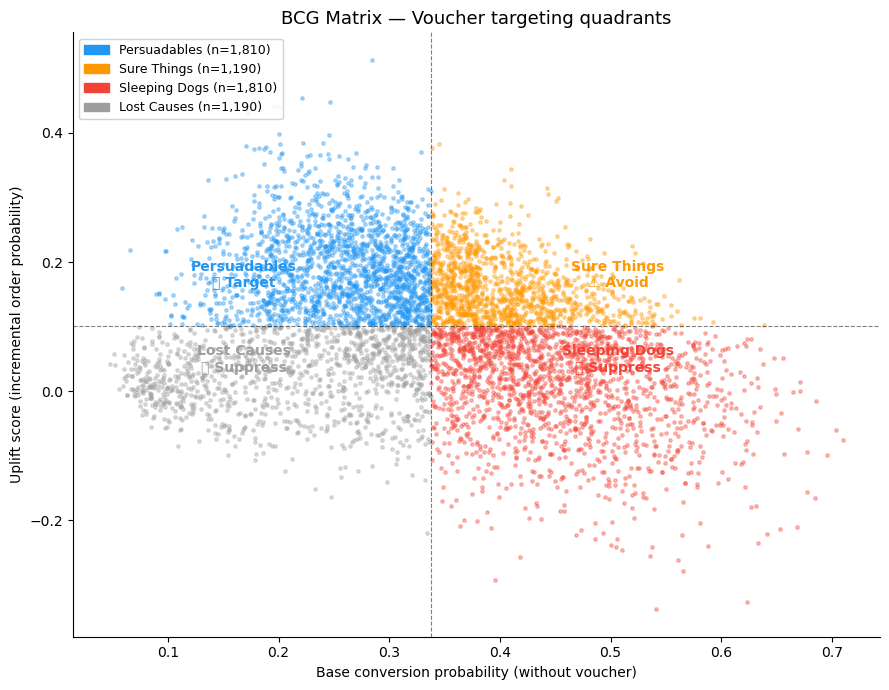


Quadrant summary:
                  tau  uplift_score
quadrant                           
Lost Causes    0.0539        0.0250
Persuadables   0.1624        0.1921
Sleeping Dogs  0.0470        0.0059
Sure Things    0.1327        0.1623


In [12]:
results = pd.DataFrame({
    "uplift_score": uplift_score,
    "base_score":   base_score,
    "tau":          tau_te,
    "churn_risk":   churn_te,
})

uplift_med = np.median(uplift_score)
base_med   = np.median(base_score)

quad_map = {
    (True,  True):  "Sure Things",
    (True,  False): "Persuadables",
    (False, True):  "Sleeping Dogs",
    (False, False): "Lost Causes",
}
results["quadrant"] = [
    quad_map[(u >= uplift_med, b >= base_med)]
    for u, b in zip(uplift_score, base_score)
]

colors_quad = {
    "Persuadables":  "#2196F3",
    "Sure Things":   "#FF9800",
    "Sleeping Dogs": "#F44336",
    "Lost Causes":   "#9E9E9E",
}

fig, ax = plt.subplots(figsize=(9, 7))
for quad, grp in results.groupby("quadrant"):
    ax.scatter(grp["base_score"], grp["uplift_score"],
               s=6, alpha=0.35, color=colors_quad[quad], label=quad, rasterized=True)

ax.axhline(uplift_med, color="black", lw=0.8, ls="--", alpha=0.5)
ax.axvline(base_med,   color="black", lw=0.8, ls="--", alpha=0.5)

ax.text(base_med * 0.5,  uplift_med * 1.6,  "Persuadables\n✅ Target",    ha="center", fontsize=10, color="#2196F3", fontweight="bold")
ax.text(base_med * 1.5,  uplift_med * 1.6,  "Sure Things\n⚠️ Avoid",      ha="center", fontsize=10, color="#FF9800", fontweight="bold")
ax.text(base_med * 0.5,  uplift_med * 0.3,  "Lost Causes\n❌ Suppress",   ha="center", fontsize=10, color="#9E9E9E", fontweight="bold")
ax.text(base_med * 1.5,  uplift_med * 0.3,  "Sleeping Dogs\n🐕 Suppress", ha="center", fontsize=10, color="#F44336", fontweight="bold")

ax.set_xlabel("Base conversion probability (without voucher)")
ax.set_ylabel("Uplift score (incremental order probability)")
ax.set_title("BCG Matrix — Voucher targeting quadrants")

counts = results["quadrant"].value_counts()
legend_labels = [f"{q} (n={counts[q]:,})" for q in colors_quad]
handles = [mpatches.Patch(color=c, label=l) for (q, c), l in zip(colors_quad.items(), legend_labels)]
ax.legend(handles=handles, loc="upper left", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("images/bcg_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nQuadrant summary:")
print(results.groupby("quadrant")[["tau", "uplift_score"]].mean().round(4))

## Takeaways

1. **Risk ≠ responsiveness.** Churn score and uplift score are structurally independent — by design here, and in practice more often than teams expect.

2. **Redemption ≠ incrementality.** Sure Things redeem at high rates. That shows up in conversion metrics. It does not show up in incremental orders.

3. **When budget is fixed, targeting is an allocation problem.** The budget curve makes this concrete: the gap between the uplift and churn curves at your budget level is the value of the switch.

4. **The T-Learner needs randomised treatment.** Historical campaign logs — where vouchers were sent to a selected subset — produce biased uplift estimates. The model recovers the selection rule, not the causal effect.

---

*Code: [github.com/shrechak](https://github.com/shrechak)*  
*Post: [medium.com/@shrechak](https://medium.com/@shrechak)*